In [10]:
import duckdb
from google.colab import userdata

# Safely retrieve HF token from Colab Secrets
HF_TOKEN = userdata.get('flyrank-read')

# Initialize DuckDB connection and secret
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf_secret (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}');")

# Set exact file path directly
EXACT_FILE_PATH = 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet'

fact_schema = con.sql(f"""
    SELECT column_name, column_type
    FROM (
        DESCRIBE SELECT * FROM read_parquet('{EXACT_FILE_PATH}')
    )
    LIMIT 20;
""").df()

print("--- FACT TABLE SCHEMA ---")
print(fact_schema)

--- FACT TABLE SCHEMA ---
                 column_name column_type
0                report_date        DATE
1             client_hash_id     VARCHAR
2            content_hash_id     VARCHAR
3             client_has_gsc     BOOLEAN
4             client_has_ga4     BOOLEAN
5         gsc_data_available     BOOLEAN
6         ga4_data_available     BOOLEAN
7            gsc_impressions      BIGINT
8                 gsc_clicks      BIGINT
9           gsc_sum_position      BIGINT
10          gsc_avg_position      DOUBLE
11             ga4_pageviews      BIGINT
12              ga4_sessions      BIGINT
13                 ga4_users      BIGINT
14      ga4_engaged_sessions      BIGINT
15  ga4_total_engagement_sec      BIGINT
16          sessions_organic      BIGINT
17           sessions_direct      BIGINT
18         sessions_referral      BIGINT
19           sessions_social      BIGINT


In [11]:
# Feature Engineering & Label Creation Query
query = f"""
WITH content_aggregates AS (
    SELECT
        client_hash_id,
        content_hash_id,
        -- Aggregate Metrics
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        AVG(gsc_avg_position) AS mean_avg_position,
        SUM(ga4_sessions) AS total_sessions,
        SUM(ga4_engaged_sessions) AS total_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS total_engagement_sec,
        SUM(sessions_organic) AS total_organic_sessions,
        COUNT(DISTINCT report_date) AS active_days
    FROM read_parquet('{EXACT_FILE_PATH}')
    WHERE gsc_data_available = TRUE
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) >= 50 -- Filter out extremely low-volume noise
)
SELECT
    client_hash_id,
    content_hash_id,
    total_impressions,
    total_clicks,
    mean_avg_position,

    -- Feature Ratios (Safely handled against division by zero)
    CASE WHEN total_impressions > 0 THEN (total_clicks * 1.0 / total_impressions) ELSE 0 END AS historical_ctr,
    CASE WHEN total_sessions > 0 THEN (total_engaged_sessions * 1.0 / total_sessions) ELSE 0 END AS engagement_rate,
    CASE WHEN total_sessions > 0 THEN (total_engagement_sec * 1.0 / total_sessions) ELSE 0 END AS avg_engagement_time_sec,
    CASE WHEN total_sessions > 0 THEN (total_organic_sessions * 1.0 / total_sessions) ELSE 0 END AS organic_session_share,

    -- Target Variable: 1 if Top-3 average position, 0 otherwise
    CASE WHEN mean_avg_position <= 3.0 THEN 1 ELSE 0 END AS is_top_tier_visible
FROM content_aggregates;
"""

df = con.sql(query).df()

print(f"Dataset Shape: {df.shape}")
print("\nClass Distribution (Target Variable):")
print(df['is_top_tier_visible'].value_counts(normalize=True))
print("\nFirst 5 Rows Preview:")
print(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset Shape: (120681, 10)

Class Distribution (Target Variable):
is_top_tier_visible
0    0.981762
1    0.018238
Name: proportion, dtype: float64

First 5 Rows Preview:
            client_hash_id           content_hash_id  total_impressions  \
0  client_3ffa76342f366962  content_31ba3b7f6586dd3f               96.0   
1  client_3ffa76342f366962  content_48a102a5060ed0e2               71.0   
2  client_3ffa76342f366962  content_bf89a688c0ec7cd7              103.0   
3  client_3ffa76342f366962  content_117ab9a954e3414c               54.0   
4  client_3ffa76342f366962  content_b9b011826cf38a50             1332.0   

   total_clicks  mean_avg_position  historical_ctr  engagement_rate  \
0           0.0          39.306194        0.000000              0.0   
1           0.0          29.678600        0.000000              0.0   
2           0.0          70.131074        0.000000              0.0   
3           0.0           5.246667        0.000000              0.0   
4           9.0        

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

# 1. Define Features (X) and Target (y)
# Exclude client/content IDs AND mean_avg_position to prevent data leakage
feature_cols = [
    'total_impressions',
    'total_clicks',
    'historical_ctr',
    'engagement_rate',
    'avg_engagement_time_sec',
    'organic_session_share'
]

X = df[feature_cols].fillna(0)
y = df['is_top_tier_visible']
groups = df['client_hash_id']

# 2. Set up GroupKFold Cross-Validation
gkf = GroupKFold(n_splits=5)

rf_aucs, dummy_aucs = [], []
rf_precisions, rf_recalls = [], []

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
dummy_model = DummyClassifier(strategy='prior')

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train Models
    rf_model.fit(X_train, y_train)
    dummy_model.fit(X_train, y_train)

    # Predict Probabilities
    rf_probs = rf_model.predict_proba(X_test)[:, 1]
    dummy_probs = dummy_model.predict_proba(X_test)[:, 1]

    # Evaluate ROC-AUC
    rf_aucs.append(roc_auc_score(y_test, rf_probs))
    dummy_aucs.append(roc_auc_score(y_test, dummy_probs))

print("=== VALIDATION RESULTS (5-Fold GroupKFold) ===")
print(f"Dummy Baseline ROC-AUC : {np.mean(dummy_aucs):.4f}")
print(f"Random Forest ROC-AUC  : {np.mean(rf_aucs):.4f}")

# 3. Extract Feature Importance
rf_model.fit(X, y)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== FEATURE IMPORTANCE RANKINGS ===")
print(importance_df.to_string(index=False))

=== VALIDATION RESULTS (5-Fold GroupKFold) ===
Dummy Baseline ROC-AUC : 0.5000
Random Forest ROC-AUC  : 0.5029

=== FEATURE IMPORTANCE RANKINGS ===
                Feature  Importance
      total_impressions    0.402287
         historical_ctr    0.270856
  organic_session_share    0.129685
           total_clicks    0.100520
avg_engagement_time_sec    0.069352
        engagement_rate    0.027300


/tmp/ipykernel_1435/1368180399.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


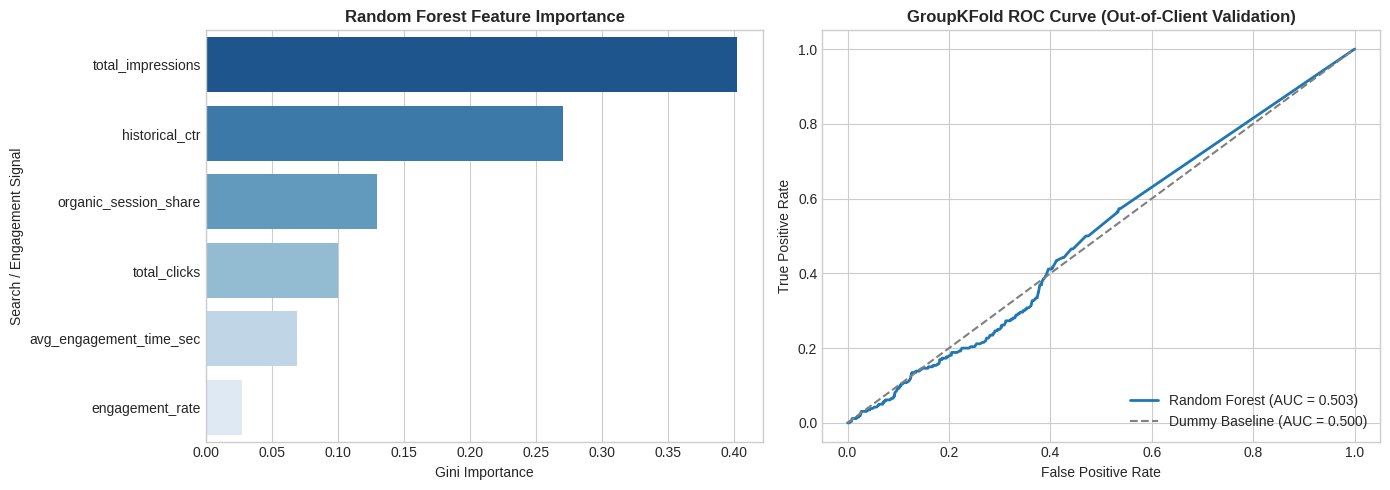

Visuals successfully generated and saved as 'capstone_results_visuals.png'!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Feature Importance
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gini Importance')
axes[0].set_ylabel('Search / Engagement Signal')

# Chart 2: ROC Curve Comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_probs)

axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {np.mean(rf_aucs):.3f})', color='#1f77b4', lw=2)
axes[1].plot(fpr_dummy, tpr_dummy, label=f'Dummy Baseline (AUC = {np.mean(dummy_aucs):.3f})', color='gray', linestyle='--')
axes[1].set_title('GroupKFold ROC Curve (Out-of-Client Validation)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('capstone_results_visuals.png', dpi=300)
plt.show()

print("Visuals successfully generated and saved as 'capstone_results_visuals.png'!")